## **Algoritmo de descenso del gradiente para un modelo de apredizaje de regresión linea de una sola variable.**

**y=a+bx**  
Es la ecuación de una recta y es nuestro modelo de regresión. Con el pretendemos aproximarnos al comportamiento de los datos que tenemos:

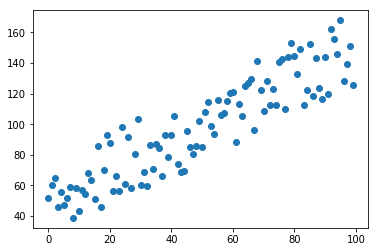

In [ ]:
#Generar un dataset artificial a partir de una recta de parametros conocidos y alterar sus valor
# de y con un ruido aleatorio (por ejemplo con la funcion random.uniform(-10,10)).

import random as rd

# Punto de intersección
a_real = 1.0

# Pendiente de la recta
b_real = 2.5

# Número de puntos del dataset
n = 50

# Valores máximos y míminos de 'x'
x_min = 0
x_max = 10

# Para generar ruido al dataset se usa la función rd.uniform(valor1, valor2)

# Valores de 'x' e 'y'
x_values = [x_min + (x_max - x_min) * i / (n - 1) for i in range(n)]
y_values = [a_real + b_real * x + rd.uniform(-10,10) for x in x_values]

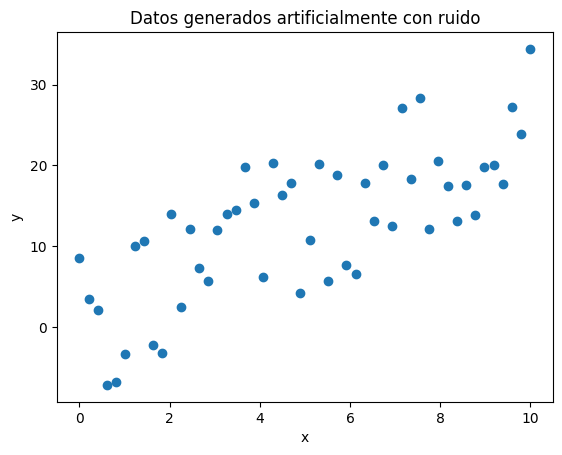

In [ ]:
import matplotlib.pyplot as plt

# Crear el gráfico de dispersión
plt.scatter(x_values, y_values)

# Añadir etiquetas y título
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos generados artificialmente con ruido")

# Mostrar la gráfica
plt.show()

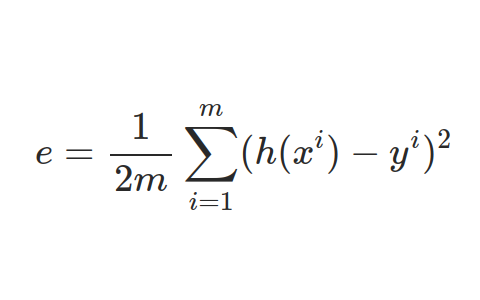

Es la ecuación del error cuadrático medio.

In [ ]:
# programar una funcion que calcule el error cuadratico medio segun la formula anterior

def error_cuadratico_medio(x_values, y_values):
    # Inicializamos los parámetros que vamos a aprender
    a = 0.0   # Punto de intersección inicial
    b = 0.0   # Pendiente de la recta inicial

    # Predicción del modelo
    h_values = [a + b * x for x in x_values]

    # Error cuadrático medio
    error = sum((h - y)**2 for h, y in zip(h_values, y_values)) / n
    return error

print(f"Error inicial: {error_cuadratico_medio(x_values, y_values):.2f}")

Error inicial: 243.35


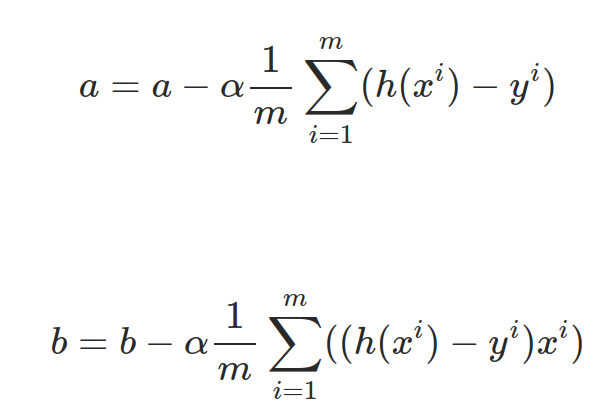

Restamos las derivadas de la ecuación del error cuadrático medio con respecto a "a" y "b"   de la ecuación de la recta (nuestro modelo o hipotesis) y=a + bx. Pero se multiplica esa derivada por alfa que es el factor de aprendizaje (recordad alfa modifica la velocidad del descenso del gradiente, si vamos muy deprisa nos podemos pasar, alfa sería muy alto; si vamos muy despacio no llegaremos a la solución en el numero de iteraciones máximo que nos hemos marcado)
Recalculamos el coste (error cuadrático medio) y se lo restamos al anterior para ver cuanto hemos reducido el error (en valor absoluto), si bajamos de un valor épsilon dado habremos terminado. Importante: Tenemos que fijarnos un número máximo de iteraciones.

In [ ]:
#Programar sendas funciones para las derivadas con respecto "a" y "b" de el error cuadratico medio
#que se corresponden con las expresiones de la celda anterior.

#Programar el algoritmo del descenso del gradiente para obtener la recta solución

import random as rd

# Parámetros reales de 'a' y 'b'
# Punto de intersección
a_real = 1.0

# Pendiente de la recta
b_real = 2.5

# Número de puntos del dataset
n = 50

# Valores máximos y míminos de 'x'
x_min = 0
x_max = 10

# Generar dataset
x_values = [x_min + (x_max - x_min) * i / (n - 1) for i in range(n)]
y_values = [a_real + b_real * x + rd.uniform(-10,10) for x in x_values]

# Parámetros iniciales
a = 0.0
b = 0.0

# Valor del rango de aprendizaje (alfa)
lr = 0.001

# Epsilon (criterio de parada)
epsilon = 0.00001

# Lista para registrar el error
errores = []

prev_error = float('inf')

# Número de iteraciones (ciclo de aprendizaje)
iteraciones = 10000

# Calcular el Descenso del Gradiente
for i in range(iteraciones):
    # Calcular valores de h
    h_values = [a + b * x for x in x_values]

    # Calcular derivada de error de 'a'
    da = lr * sum((h - y for h, y in zip(h_values, y_values)))

    # Calcular derivada de error de 'b'
    db = lr * sum(((h - y) * x for h, y, x in zip(h_values, y_values, x_values)))

    # Actualizar valores de 'a' y 'b'
    a -= da
    b -= db

    # Calcular error cuadrático medio
    error = sum((h - y)**2 for h, y in zip(h_values, y_values)) / n
    errores.append(error)

    # Comprobar si el error cuadratico promedio está bajando
    if i % 100 == 0:
        error = sum((h - y)**2 for h, y in zip(h_values, y_values)) / n
        print(f"Iteración {i}: a={a:.2f}, b={b:.2f}, Error={error:.2f}")

    # Comprobar convergencia con epsilon
    if abs(prev_error - error) < epsilon:
        print(f"\nConvergencia alcanzada en la iteración {i} con error {error:.6f}")
        break

    prev_error = error

# Resultado final
print(f"\nValores finales: a={a:.4f}, b={b:.4f}, Error={error:.6f}")

Iteración 0: a=0.65, b=4.25, Error=251.74
Iteración 100: a=1.42, b=2.32, Error=36.11
Iteración 200: a=1.71, b=2.27, Error=36.07

Convergencia alcanzada en la iteración 286 con error 36.068403

Valores finales: a=1.7844, b=2.2608, Error=36.068403


Podemos almacenar las diferencias entre el e.c.m de una iteración anterior y el de la siguiente, así podremos visualizar como ha ido progresando el aprendizaje.
Muestra con mathplotlib la curva que representa el proceso de reducción del error.

[Enlace a un cuaderno con ejemplos sencillos de uso de mathplotlib](https://colab.research.google.com/drive/18EXPYXumWeJX7ceXPK2vsgI5NZHL3j4-?usp=sharing)

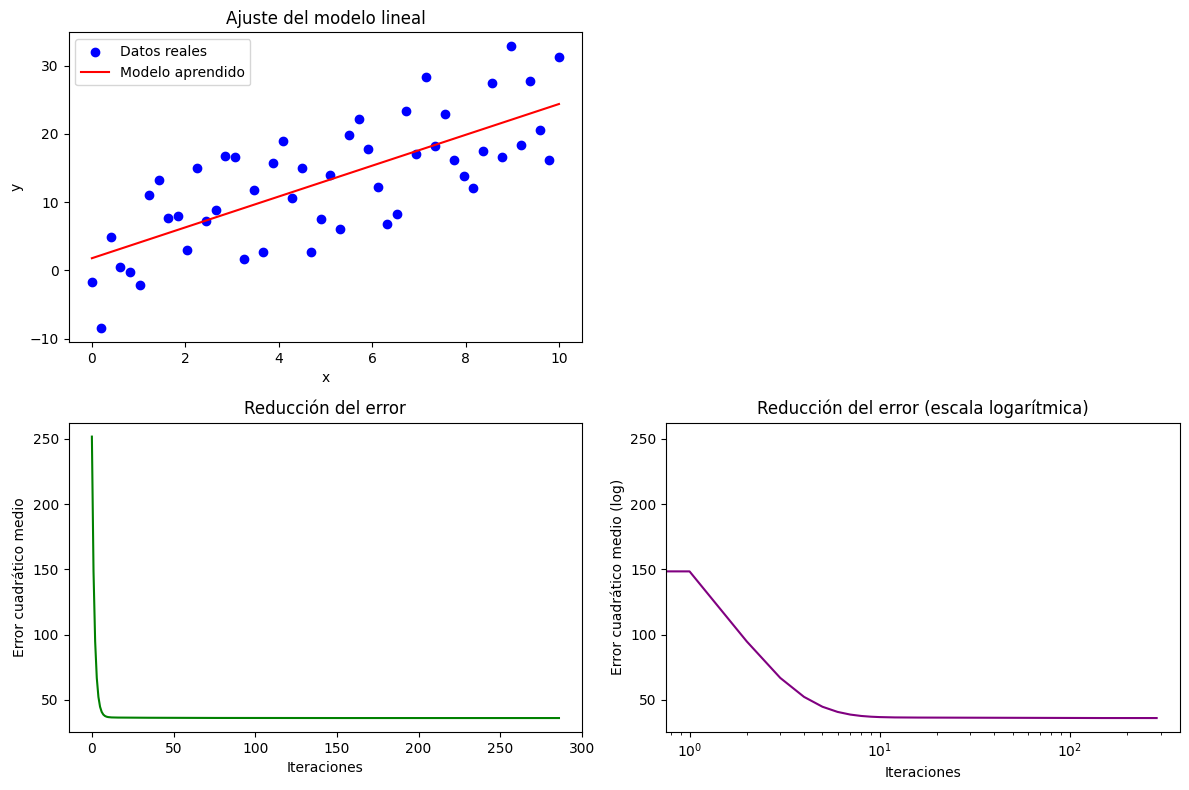

In [ ]:
#Usando mathplotlib muestra la curva descrita en el parrafo anterior

import matplotlib.pyplot as plt

# Crear figura con 2 filas y 2 columnas
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Gráfica del modelo aprendido (fila 1, ocupa las 2 columnas)
axs[0, 0].scatter(x_values, y_values, color='blue', label='Datos reales')
axs[0, 0].plot(x_values, [a + b * x for x in x_values], color='red', label='Modelo aprendido')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('y')
axs[0, 0].set_title('Ajuste del modelo lineal')
axs[0, 0].legend()

# Ocultar el subplot vacío (posición [0,1]) ya que el de arriba ocupa todo el ancho
fig.delaxes(axs[0, 1])

# Gráfica del error normal (fila 2, columna 1)
axs[1, 0].plot(range(len(errores)), errores, color='green')
axs[1, 0].set_xlabel('Iteraciones')
axs[1, 0].set_ylabel('Error cuadrático medio')
axs[1, 0].set_title('Reducción del error')

# Gráfica del error logarítmico (fila 2, columna 2)
axs[1, 1].plot(range(len(errores)), errores, color='purple')
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel('Iteraciones')
axs[1, 1].set_ylabel('Error cuadrático medio (log)')
axs[1, 1].set_title('Reducción del error (escala logarítmica)')

# Ajustar espacios
plt.tight_layout()
plt.show()

# Resumen y Comparación de Resultados

## Gráfica del Modelo Lineal Aprendido
- La recta ajustada (en rojo) sigue la tendencia general de los datos generados.
- Los puntos azules muestran los datos reales con ruido aleatorio.
- Aunque hay dispersión en los datos, el modelo logra aproximarse bastante bien a la relación lineal subyacente.

## Gráfica de la Reducción del Error (MSE)
- El error cuadrático medio disminuye progresivamente durante las iteraciones.
- Inicialmente, la reducción es rápida, mostrando que el modelo se ajusta rápidamente a los datos.
- Con el tiempo, la curva se aplana, indicando que el aprendizaje converge y que los cambios en los parámetros ya son mínimos.

## Comparación de Escalas (Normal vs Logarítmica)
- La escala normal muestra la magnitud real del error y su descenso.
- La escala logarítmica permite visualizar mejor la convergencia en las últimas iteraciones, donde los cambios son muy pequeños.
- Ambas gráficas confirman que el algoritmo de descenso de gradiente converge correctamente y que el epsilon definido funciona como criterio de parada.

## Conclusión
- El modelo lineal aprendido es consistente con los datos generados.
- El descenso del error muestra una convergencia estable, validando la efectividad del algoritmo.
- La escala logarítmica es útil para observar la mejora en etapas finales del entrenamiento.
